## Imports

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import gaussian_kde, chi2
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt

## Load Dataset

In [2]:
df = pd.read_csv('dataset.csv')
mapping = {
    'Insufficient_Weight':'Insufficient',
    'Normal_Weight':'Normal',
    'Overweight_Level_I':'Overweight',
    'Overweight_Level_II':'Overweight',
    'Obesity_Type_I':'Obesity',
    'Obesity_Type_II':'Obesity',
    'Obesity_Type_III':'Obesity'
}
df['Obesity4'] = df['NObeyesdad'].map(mapping)
df['Obesity4'] = pd.Categorical(df['Obesity4'], categories=['Insufficient','Normal','Overweight','Obesity'], ordered=True)
continuous = ['Age','Height','Weight','FCVC','NCP','CH2O','FAF']
binary = ['FAVC','SMOKE','SCC']
categorical = ['Gender','family_history_with_overweight','CAEC','MTRANS']
all_vars = continuous + binary + categorical

## Utility Functions

In [3]:
def pmf_cdf(s):
    v = s.dropna()
    c = v.value_counts().sort_index()
    pmf = c / c.sum()
    return pmf, pmf.cumsum()

def kde_pdf_cdf(s, grid=200):
    d = s.dropna().values
    k = gaussian_kde(d)
    mn, mx = d.min(), d.max()
    pad = 0.05 * (mx - mn) if mx > mn else 1
    x = np.linspace(mn - pad, mx + pad, grid)
    pdf = k(x)
    pdf = pdf / np.trapz(pdf, x)
    cdf = np.cumsum(pdf)
    cdf = cdf / cdf[-1]
    return x, pdf, cdf, k

def mean_ci(x, a=0.05):
    x = np.asarray(x)
    m = x.mean(); s = x.std(ddof=1); n = len(x)
    z = stats.norm.ppf(1 - a/2)
    e = z * s / np.sqrt(n)
    return m, m - e, m + e

def var_ci(x, a=0.05):
    x = np.asarray(x)
    n = len(x)
    v = x.var(ddof=1)
    l = (n - 1) * v / chi2.ppf(1 - a/2, n - 1)
    u = (n - 1) * v / chi2.ppf(a/2, n - 1)
    return v, l, u

def prop_ci(c, n, a=0.05):
    if n == 0:
        return np.nan, np.nan, np.nan
    p = c / n
    z = stats.norm.ppf(1 - a/2)
    se = np.sqrt(p * (1 - p) / n)
    return p, p - z * se, p + z * se

## Task 1: Marginal Distributions

In [4]:
support = {}
marginals = {}
for col in all_vars:
    s = df[col]
    if col in continuous:
        support[col] = {'type':'continuous','min':float(s.min()),'max':float(s.max())}
        x, pdf, cdf, _ = kde_pdf_cdf(s)
        marginals[col] = {'x':x,'pdf':pdf,'cdf':cdf}
    else:
        support[col] = {'type':'discrete','values':sorted(s.dropna().unique().tolist())}
        pmf, cdf = pmf_cdf(s)
        marginals[col] = {'pmf':pmf,'cdf':cdf}
support

C:\Users\eldeivid\AppData\Local\Temp\ipykernel_44280\1710071921.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pdf = pdf / np.trapz(pdf, x)


{'Age': {'type': 'continuous', 'min': 14.0, 'max': 61.0},
 'Height': {'type': 'continuous', 'min': 1.45, 'max': 1.98},
 'Weight': {'type': 'continuous', 'min': 39.0, 'max': 173.0},
 'FCVC': {'type': 'continuous', 'min': 1.0, 'max': 3.0},
 'NCP': {'type': 'continuous', 'min': 1.0, 'max': 4.0},
 'CH2O': {'type': 'continuous', 'min': 1.0, 'max': 3.0},
 'FAF': {'type': 'continuous', 'min': 0.0, 'max': 3.0},
 'FAVC': {'type': 'discrete', 'values': ['no', 'yes']},
 'SMOKE': {'type': 'discrete', 'values': ['no', 'yes']},
 'SCC': {'type': 'discrete', 'values': ['no', 'yes']},
 'Gender': {'type': 'discrete', 'values': ['Female', 'Male']},
 'family_history_with_overweight': {'type': 'discrete',
  'values': ['no', 'yes']},
 'CAEC': {'type': 'discrete',
  'values': ['Always', 'Frequently', 'Sometimes', 'no']},
 'MTRANS': {'type': 'discrete',
  'values': ['Automobile',
   'Bike',
   'Motorbike',
   'Public_Transportation',
   'Walking']}}

### Plot Marginal PDF and CDF for Weight

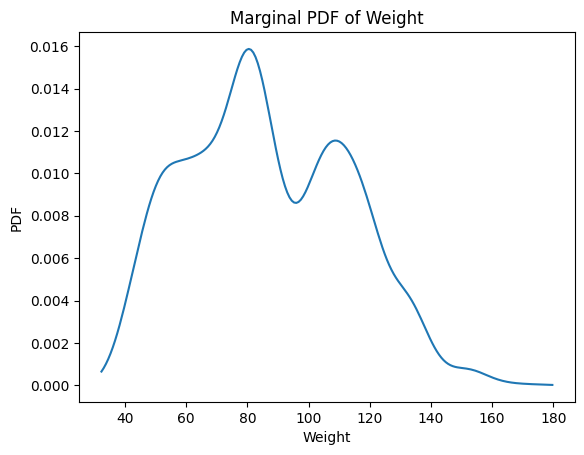

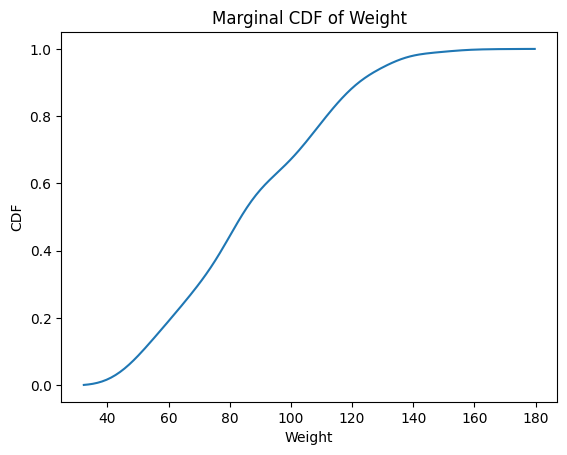

In [5]:
x = marginals['Weight']['x']
pdf = marginals['Weight']['pdf']
cdf = marginals['Weight']['cdf']
fig, ax = plt.subplots()
ax.plot(x, pdf)
ax.set_xlabel('Weight')
ax.set_ylabel('PDF')
ax.set_title('Marginal PDF of Weight')
plt.show()
fig, ax = plt.subplots()
ax.plot(x, cdf)
ax.set_xlabel('Weight')
ax.set_ylabel('CDF')
ax.set_title('Marginal CDF of Weight')
plt.show()

## Task 2: Continuous Features

In [6]:
rows = []
for col in continuous:
    g = df.groupby('Obesity4', observed=False)
    for lvl, sub in g:
        x = sub[col].dropna().values
        if len(x) > 1:
            m, l, u = mean_ci(x)
            v, lv, uv = var_ci(x)
            rows.append([col, lvl, len(x), m, l, u, v, lv, uv])
cont_summary = pd.DataFrame(rows, columns=['feature','level','n','mean','mean_l','mean_u','var','var_l','var_u'])
cont_summary.head()

,feature,level,n,mean,mean_l,mean_u,var,var_l,var_u
0,Age,Insufficient,272,19.783237,19.465992,20.100483,7.126287,6.063621,8.496624
1,Age,Normal,287,21.738676,21.149017,22.328335,25.976926,22.194531,30.821435
2,Age,Overweight,580,25.207328,24.607249,25.807406,54.368514,48.611529,61.217989
3,Age,Obesity,972,25.806181,25.434079,26.178283,35.034324,32.115475,38.372118
4,Height,Insufficient,272,1.691117,1.679270,1.702964,0.009937,0.008456,0.011848


In [7]:
a = []
for col in continuous:
    gs = [g.dropna().values for _, g in df.groupby('Obesity4', observed=False)[col]]
    F, p = stats.f_oneway(*gs)
    a.append([col, F, p])
anova_df = pd.DataFrame(a, columns=['feature','F','p'])
anova_df

,feature,F,p
0,Age,94.892632,1.319997e-57
1,Height,16.364722,1.632417e-10
2,Weight,1992.518260,0.000000e+00
3,FCVC,33.269430,5.253959e-21
4,NCP,20.369308,5.190784e-13
5,CH2O,15.355907,6.958861e-10
6,FAF,23.588062,5.152178e-15


In [8]:
tuk = []
for col in continuous:
    if anova_df.loc[anova_df['feature'] == col, 'p'].values[0] < 0.05:
        m = (df[col].notna()) & (df['Obesity4'].notna())
        t = pairwise_tukeyhsd(endog=df.loc[m, col], groups=df.loc[m, 'Obesity4'], alpha=0.05)
        d = pd.DataFrame(t._results_table.data[1:], columns=t._results_table.data[0])
        d['feature'] = col
        tuk.append(d)
if tuk:
    tukey_all = pd.concat(tuk, ignore_index=True)
    r, padj, _, _ = multipletests(tukey_all['p-adj'].astype(float), method='fdr_bh')
    tukey_all['p_fdr'] = padj
    tukey_all['reject_fdr'] = r
else:
    tukey_all = pd.DataFrame()
tukey_all.head()

,group1,group2,meandiff,p-adj,lower,upper,reject,feature,p_fdr,reject_fdr
0,Insufficient,Normal,1.9554,0.0006,0.6586,3.2523,True,Age,0.000969,True
1,Insufficient,Obesity,6.0229,0.0000,4.9717,7.0742,True,Age,0.000000,True
2,Insufficient,Overweight,5.4241,0.0000,4.2979,6.5503,True,Age,0.000000,True
3,Normal,Obesity,4.0675,0.0000,3.0380,5.0970,True,Age,0.000000,True
4,Normal,Overweight,3.4687,0.0000,2.3626,4.5747,True,Age,0.000000,True


### Boxplot of Weight by Obesity Level

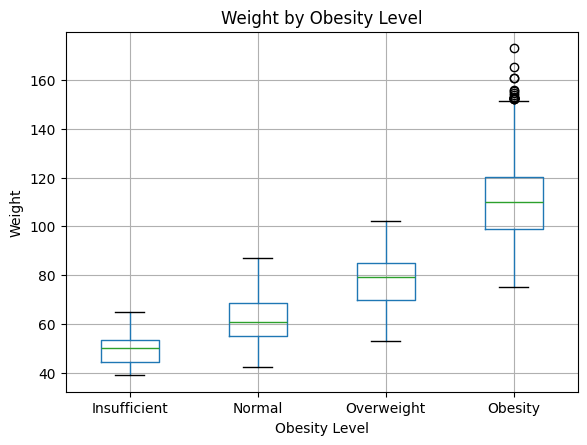

In [9]:
fig, ax = plt.subplots()
df.boxplot(column='Weight', by='Obesity4', ax=ax)
ax.set_title('Weight by Obesity Level')
ax.set_xlabel('Obesity Level')
ax.set_ylabel('Weight')
plt.suptitle('')
plt.show()

## Task 3: Binary and Categorical

In [10]:
cp = []
for col in binary + categorical:
    g = df.groupby('Obesity4', observed=False)
    for lvl, sub in g:
        c = sub[col].value_counts()
        n = c.sum()
        for v, count in c.items():
            p, l, u = prop_ci(count, n)
            cp.append([col, v, lvl, n, count, p, l, u])
cat_prev_df = pd.DataFrame(cp, columns=['feature','category','level','n','count','p','l','u'])
cat_prev_df.head()

,feature,category,level,n,count,p,l,u
0,FAVC,yes,Insufficient,272,221,0.812500,0.766115,0.858885
1,FAVC,no,Insufficient,272,51,0.187500,0.141115,0.233885
2,FAVC,yes,Normal,287,208,0.724739,0.673065,0.776412
3,FAVC,no,Normal,287,79,0.275261,0.223588,0.326935
4,FAVC,yes,Overweight,580,484,0.834483,0.804237,0.864729


In [11]:
tests = []
pvals = []
for col in binary + categorical:
    tab = pd.crosstab(df['Obesity4'], df[col])
    chi, p, dof, exp = stats.chi2_contingency(tab)
    if tab.shape == (2,2) and (exp < 5).any():
        _, p = stats.fisher_exact(tab.values)
        chi = np.nan
        dof = 1
    tests.append([col, chi, dof, p])
    pvals.append(p)
r, padj, _, _ = multipletests(pvals, method='fdr_bh')
out = []
for i, row in enumerate(tests):
    out.append(row + [padj[i], r[i]])
cat_tests_df = pd.DataFrame(out, columns=['feature','chi2','dof','p','p_fdr','reject_fdr'])
cat_tests_df

,feature,chi2,dof,p,p_fdr,reject_fdr
0,FAVC,186.518899,3,3.447840e-40,8.044960e-40,True
1,SMOKE,13.901526,3,3.042303e-03,3.042303e-03,True
2,SCC,79.642730,3,3.661575e-17,5.126206e-17,True
3,Gender,32.196306,3,4.757888e-07,5.550870e-07,True
4,family_history_with_overweight,575.571169,3,1.990907e-124,6.968173e-124,True
5,CAEC,715.051862,9,4.014705e-148,2.810294e-147,True
6,MTRANS,150.150517,12,5.284884e-26,9.248548e-26,True


### Bar Plot of FAVC Prevalence by Obesity Level

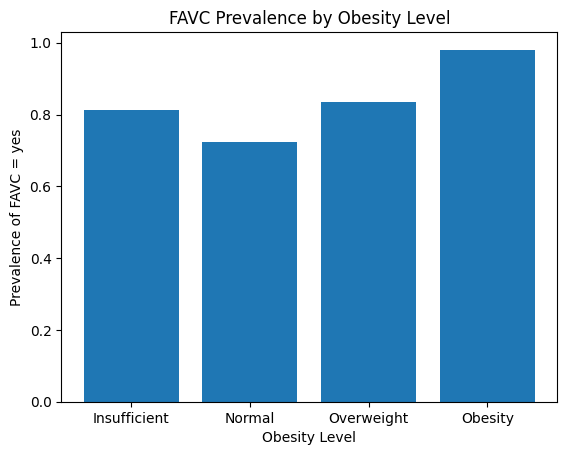

In [12]:
sub = cat_prev_df[(cat_prev_df['feature']=='FAVC') & (cat_prev_df['category']=='yes')]
fig, ax = plt.subplots()
ax.bar(sub['level'], sub['p'])
ax.set_xlabel('Obesity Level')
ax.set_ylabel('Prevalence of FAVC = yes')
ax.set_title('FAVC Prevalence by Obesity Level')
plt.show()

## Task 4: Conditional Distributions

In [13]:
cond = {}
for col in all_vars:
    cond[col] = {}
    for lvl, sub in df.groupby('Obesity4', observed=False):
        s = sub[col].dropna()
        if col in continuous:
            x, pdf, cdf, _ = kde_pdf_cdf(s)
            cond[col][lvl] = {'x':x,'pdf':pdf,'cdf':cdf}
        else:
            pmf, cdf = pmf_cdf(s)
            cond[col][lvl] = {'pmf':pmf,'cdf':cdf}
list(cond.keys())

C:\Users\eldeivid\AppData\Local\Temp\ipykernel_44280\1710071921.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pdf = pdf / np.trapz(pdf, x)


['Age',
 'Height',
 'Weight',
 'FCVC',
 'NCP',
 'CH2O',
 'FAF',
 'FAVC',
 'SMOKE',
 'SCC',
 'Gender',
 'family_history_with_overweight',
 'CAEC',
 'MTRANS']

### Conditional PDFs of Weight by Obesity Level

C:\Users\eldeivid\AppData\Local\Temp\ipykernel_44280\1710071921.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pdf = pdf / np.trapz(pdf, x)


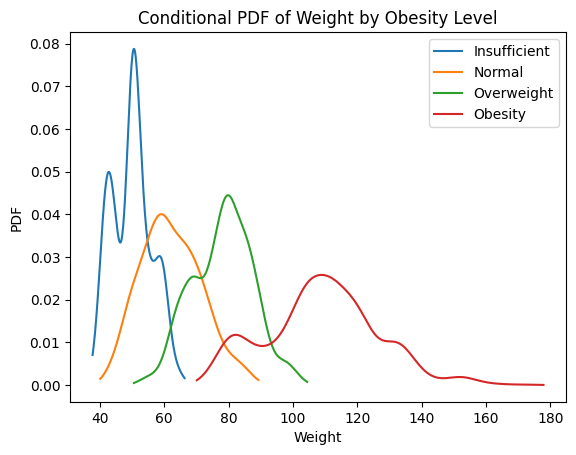

In [14]:
fig, ax = plt.subplots()
for lvl in df['Obesity4'].cat.categories:
    d = df[df['Obesity4']==lvl]['Weight']
    x, pdf, cdf, _ = kde_pdf_cdf(d)
    ax.plot(x, pdf, label=str(lvl))
ax.set_xlabel('Weight')
ax.set_ylabel('PDF')
ax.set_title('Conditional PDF of Weight by Obesity Level')
ax.legend()
plt.show()

## Task 5: Model-Based Expectations

In [15]:
mom = []
for col in continuous:
    for lvl, sub in df.groupby('Obesity4', observed=False):
        x = sub[col].dropna().values
        if len(x) > 10:
            g, pdf, cdf, _ = kde_pdf_cdf(pd.Series(x))
            dx = g[1] - g[0]
            m_mod = np.sum(g * pdf) * dx
            v_mod = np.sum((g - m_mod)**2 * pdf) * dx
            m_s = x.mean(); v_s = x.var(ddof=1)
            mom.append([col, lvl, m_mod, m_s, m_mod - m_s, v_mod, v_s, v_mod - v_s])
mom_df = pd.DataFrame(mom, columns=['feature','level','mean_model','mean_sample','diff_mean','var_model','var_sample','diff_var'])
mom_df.head()

C:\Users\eldeivid\AppData\Local\Temp\ipykernel_44280\1710071921.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pdf = pdf / np.trapz(pdf, x)


,feature,level,mean_model,mean_sample,diff_mean,var_model,var_sample,diff_var
0,Age,Insufficient,19.794231,19.783237,0.010994,7.695271,7.126287,0.568984
1,Age,Normal,21.734974,21.738676,-0.003702,28.155590,25.976926,2.178665
2,Age,Overweight,25.266030,25.207328,0.058703,57.110544,54.368514,2.742030
3,Age,Obesity,25.806651,25.806181,0.000470,37.134036,35.034324,2.099711
4,Height,Insufficient,1.697556,1.691117,0.006439,0.009910,0.009937,-0.000027


## Task 6: ROC and Discriminative Intervals

In [16]:
def roc_thr(x, y):
    fpr, tpr, thr = roc_curve(y, x)
    J = tpr - fpr
    i = np.argmax(J)
    return fpr, tpr, thr, thr[i]

def eval_ovr(df, feat, lvl, n_boot=1000, seed=0):
    r = np.random.default_rng(seed)
    d = df[[feat, 'Obesity4']].dropna()
    x = d[feat].values
    y = (d['Obesity4'] == lvl).astype(int).values
    fpr, tpr, thr, bthr = roc_thr(x, y)
    auc0 = roc_auc_score(y, x)
    aucs = []
    for _ in range(n_boot):
        idx = r.integers(0, len(x), len(x))
        aucs.append(roc_auc_score(y[idx], x[idx]))
    aucs = np.array(aucs)
    lo, hi = np.percentile(aucs, [2.5, 97.5])
    yp = (x > bthr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, yp, labels=[0,1]).ravel()
    alpha = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    beta = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    power = 1 - beta if not np.isnan(beta) else np.nan
    pos = x[y == 1]
    neg = x[y == 0]
    ks, pks = stats.ks_2samp(pos, neg)
    if pos.mean() >= neg.mean():
        A = bthr; B = float('inf')
    else:
        A = float('-inf'); B = bthr
    return [feat, lvl, auc0, lo, hi, bthr, A, B, tn, fp, fn, tp, alpha, beta, power, ks, pks]

disc = []
for f in continuous:
    for lvl in df['Obesity4'].cat.categories:
        disc.append(eval_ovr(df, f, lvl))
disc_df = pd.DataFrame(disc, columns=['feature','level','auc','auc_l','auc_u','thr','a','b','tn','fp','fn','tp','alpha','beta','power','ks','ks_p'])
disc_df.head()

,feature,level,auc,auc_l,auc_u,thr,a,b,tn,fp,fn,tp,alpha,beta,power,ks,ks_p
0,Age,Insufficient,0.203682,0.180348,0.227154,16.000000,-inf,16.000000,9,1830,2,270,0.995106,0.007353,0.992647,0.473845,4.736574e-49
1,Age,Normal,0.339387,0.307758,0.371717,61.000000,-inf,61.000000,1824,0,287,0,0.000000,1.000000,0.000000,0.291615,3.862624e-19
2,Age,Overweight,0.527747,0.499071,0.556225,26.047077,26.047077,inf,1225,306,394,186,0.199869,0.679310,0.320690,0.122544,5.743854e-06
3,Age,Obesity,0.687571,0.665191,0.712291,22.200779,22.200779,inf,720,419,281,691,0.367867,0.289095,0.710905,0.344068,1.402693e-55
4,Height,Insufficient,0.468953,0.431770,0.504581,1.686936,-inf,1.686936,809,1030,109,163,0.560087,0.400735,0.599265,0.144378,8.914262e-05


### ROC Curve Example for Weight Detecting Obesity

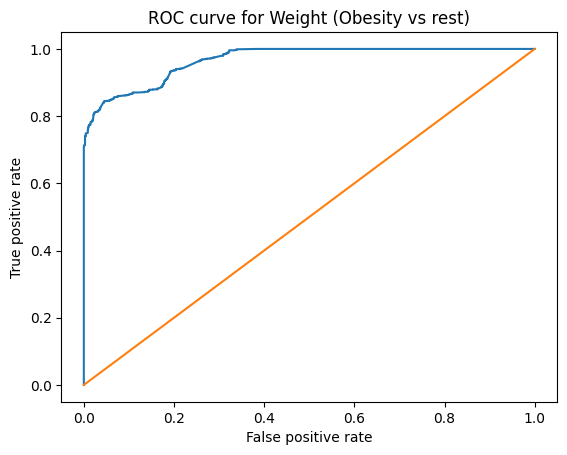

In [17]:
d = df[['Weight','Obesity4']].dropna()
x = d['Weight'].values
y = (d['Obesity4']=='Obesity').astype(int).values
fpr, tpr, thr = roc_curve(y, x)
fig, ax = plt.subplots()
ax.plot(fpr, tpr)
ax.plot([0,1],[0,1])
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curve for Weight (Obesity vs rest)')
plt.show()

In [18]:
best_power = disc_df.sort_values('power', ascending=False).head(10)
best_alpha = disc_df.sort_values('alpha', ascending=True).head(10)
best_power, best_alpha

(   feature         level       auc     auc_l     auc_u        thr          a  \
 0      Age  Insufficient  0.203682  0.180348  0.227154  16.000000       -inf   
 10  Weight    Overweight  0.382234  0.356906  0.403987  60.117993       -inf   
 9   Weight        Normal  0.168930  0.151175  0.185214  45.000000       -inf   
 19     NCP       Obesity  0.481067  0.458258  0.503432   1.000283   1.000283   
 14    FCVC    Overweight  0.366199  0.340478  0.391421   1.570089       -inf   
 11  Weight       Obesity  0.966690  0.960805  0.972746  89.938890  89.938890   
 22    CH2O    Overweight  0.512428  0.484394  0.538591   1.622214   1.622214   
 26     FAF    Overweight  0.493913  0.466744  0.519307   0.261274       -inf   
 15    FCVC       Obesity  0.608980  0.586207  0.631870   2.014194   2.014194   
 3      Age       Obesity  0.687571  0.665191  0.712291  22.200779  22.200779   
 
             b    tn    fp   fn   tp     alpha      beta     power        ks  \
 0   16.000000     9  1830 